In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.dataset.kitti_dataset import KittiDataset
from src.geometry.boxes import box_corners_from_parameters, get_lidar_boxes
from src.geometry.transforms import lidar_xy_to_bev
from src.inference.decode import decode_predictions
from src.models.bev_detector import BEVDetector
from src.preprocessing.bev import bev_projection

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BEVDetector().to(device)

checkpoint_path = PROJECT_ROOT / "outputs" / "bev_detector_multiscale_full.pth"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

dataset = KittiDataset(PROJECT_ROOT / "data" / "KITTI", split="training")
validation_indices = checkpoint["split"]["validation_indices"]
sample_index = validation_indices[2]
sample = dataset[sample_index]

bev = bev_projection(sample["points"])
bev_tensor = torch.from_numpy(bev).float().unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(bev_tensor)

detections = decode_predictions(
    outputs,
    score_threshold=0.30,
    top_k=50,
    min_center_distance=1.5,
)
gt_boxes = get_lidar_boxes(sample["labels"], sample["calib"])

print("Validation index:", sample_index)
print("Predictions:", len(detections))
print("Ground-truth cars:", len(gt_boxes))


Validation index: 7366
Predictions: 8
Ground-truth cars: 7


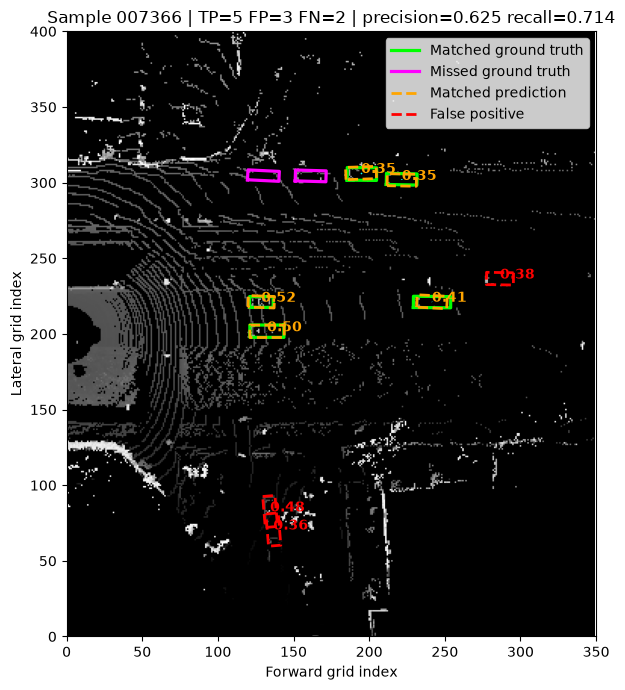

In [2]:
# Match predictions to ground truth by center distance.
# This is the same one-to-one, 2-metre rule used by the validation metrics.
match_distance_m = 2.0
matched_pairs = []
matched_gt_indices = set()
matched_detection_indices = set()

for detection_index, detection in sorted(
    enumerate(detections),
    key=lambda item: item[1]["score"],
    reverse=True,
):
    best_gt_index = None
    best_distance = match_distance_m

    for gt_index, box in enumerate(gt_boxes):
        if gt_index in matched_gt_indices:
            continue

        distance = np.hypot(
            detection["center_x"] - box["center_x"],
            detection["center_y"] - box["center_y"],
        )
        if distance <= best_distance:
            best_distance = distance
            best_gt_index = gt_index

    if best_gt_index is not None:
        matched_gt_indices.add(best_gt_index)
        matched_detection_indices.add(detection_index)
        matched_pairs.append((detection_index, best_gt_index, best_distance))

false_positive_indices = (
    set(range(len(detections))) - matched_detection_indices
)
missed_gt_indices = set(range(len(gt_boxes))) - matched_gt_indices

tp = len(matched_pairs)
fp = len(false_positive_indices)
fn = len(missed_gt_indices)
precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0


def bev_box(box):
    corners = box_corners_from_parameters(
        box["center_x"],
        box["center_y"],
        box["length"],
        box["width"],
        box["yaw"],
    )
    corners = lidar_xy_to_bev(corners)
    return np.vstack([corners, corners[0]])


def bev_center(box):
    center = np.array([[box["center_x"], box["center_y"]]])
    return lidar_xy_to_bev(center)[0]


fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(
    bev[0].T,
    origin="lower",
    cmap="gray",
    aspect="equal",
)

# Green = matched ground truth; magenta = missed ground truth.
for gt_index, box in enumerate(gt_boxes):
    matched = gt_index in matched_gt_indices
    color = "lime" if matched else "magenta"
    label = "Matched ground truth" if matched else "Missed ground truth"
    closed = bev_box(box)
    ax.plot(
        closed[:, 0],
        closed[:, 1],
        color=color,
        linewidth=2.3,
        label=label,
    )

# Orange = matched prediction; red = false positive.
for detection_index, detection in enumerate(detections):
    matched = detection_index in matched_detection_indices
    color = "orange" if matched else "red"
    label = "Matched prediction" if matched else "False positive"
    closed = bev_box(detection)

    ax.plot(
        closed[:, 0],
        closed[:, 1],
        color=color,
        linestyle="--",
        linewidth=2,
        label=label,
    )

    center = bev_center(detection)
    ax.text(
        center[0],
        center[1],
        f'{detection["score"]:.2f}',
        color=color,
        weight="bold",
    )

# Cyan dotted line connects each true-positive pair.
for detection_index, gt_index, distance in matched_pairs:
    prediction_center = bev_center(detections[detection_index])
    gt_center = bev_center(gt_boxes[gt_index])
    ax.plot(
        [prediction_center[0], gt_center[0]],
        [prediction_center[1], gt_center[1]],
        color="cyan",
        linestyle=":",
        linewidth=1.2,
    )

# Remove repeated legend labels.
handles, labels = ax.get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))
ax.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="upper right",
)

ax.set_xlim(0, bev.shape[1])
ax.set_ylim(0, bev.shape[2])
ax.set_xlabel("Forward grid index")
ax.set_ylabel("Lateral grid index")
ax.set_title(
    f"Sample {sample['id']} | TP={tp} FP={fp} FN={fn} | "
    f"precision={precision:.3f} recall={recall:.3f}"
)
fig.tight_layout()
plt.show()
